# Explanation of the provided code:

| Step             | Iris Dataset                       | Diamonds Dataset               |
| ---------------- | ---------------------------------- | ------------------------------ |
| Preprocessing    | StandardScaler                     | StandardScaler + OneHotEncoder |
| Model            | `SVC(kernel='rbf')`                | `SVC(kernel='rbf')`            |
| Train/test split | 80/20                              | 80/20                          |
| Evaluation       | Accuracy, Report, Confusion Matrix | Same                           |

You can experiment with:

kernel='linear' or kernel='poly'

C and gamma hyperparameters

Other classifiers (e.g., RandomForestClassifier) for comparison

SVM is sensitive to feature scaling, so StandardScaler() is crucial.

In [1]:
# =============================
# 1. IMPORT LIBRARIES
# =============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

=== SVM on Iris Dataset ===
Accuracy (Iris): 1.0

Classification Report (Iris):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



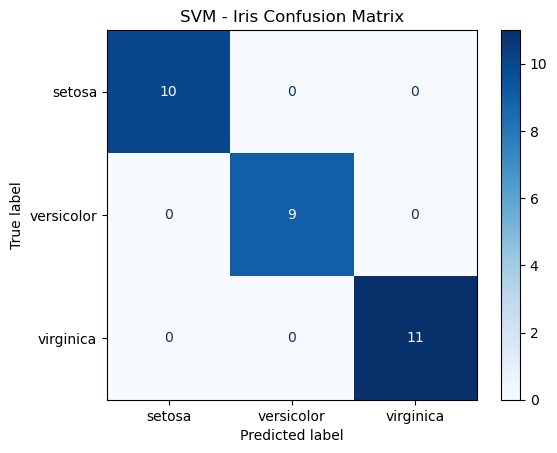

In [2]:
# =============================
# 2. SVM on Iris Dataset
# =============================
print("=== SVM on Iris Dataset ===")

# Load dataset
iris = sns.load_dataset('iris')

# Define features and target
X_iris = iris.drop(columns=['species'])
y_iris = iris['species']

# Split dataset
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Create pipeline: scaling + SVM
iris_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))  # Radial Basis Function kernel
])

# Train the model
iris_pipeline.fit(X_train_iris, y_train_iris)

# Predict and evaluate
y_pred_iris = iris_pipeline.predict(X_test_iris)

print("Accuracy (Iris):", accuracy_score(y_test_iris, y_pred_iris))
print("\nClassification Report (Iris):\n", classification_report(y_test_iris, y_pred_iris))

# Confusion Matrix
cm_iris = confusion_matrix(y_test_iris, y_pred_iris, labels=iris['species'].unique())
disp_iris = ConfusionMatrixDisplay(confusion_matrix=cm_iris, display_labels=iris['species'].unique())
disp_iris.plot(cmap='Blues')
plt.title("SVM - Iris Confusion Matrix")
plt.show()

=== SVM on Diamonds Dataset ===
Accuracy (Diamonds): 0.6883333333333334

Classification Report (Diamonds):
               precision    recall  f1-score   support

        Fair       0.93      0.72      0.81        18
        Good       0.46      0.39      0.42        49
       Ideal       0.79      0.89      0.84       243
     Premium       0.65      0.85      0.73       156
   Very Good       0.48      0.24      0.32       134

    accuracy                           0.69       600
   macro avg       0.66      0.62      0.63       600
weighted avg       0.66      0.69      0.66       600



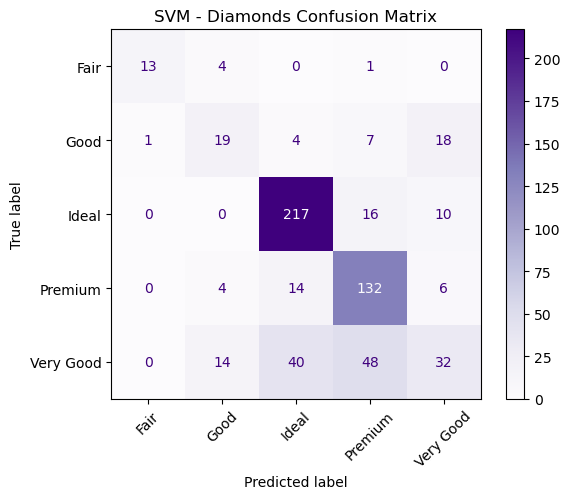

In [3]:
# =============================
# 3. SVM on Diamonds Dataset
# =============================
print("=== SVM on Diamonds Dataset ===")

# Load dataset
diamonds = sns.load_dataset('diamonds')  # use sns for consistent column names
# For full version, use: pd.read_csv("path/to/diamonds.csv")

# Use a subset for quick training
diamonds_sample = diamonds.sample(3000, random_state=42)

# Target and features
X_diamond = diamonds_sample.drop(columns=['cut'])
y_diamond = diamonds_sample['cut']

# Identify categorical and numerical features
cat_features = ['color', 'clarity']
num_features = [col for col in X_diamond.columns if col not in cat_features]

# Preprocessor
diamond_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_features),
    ('num', StandardScaler(), num_features)
])

# Pipeline
diamond_pipeline = Pipeline([
    ('preprocessor', diamond_preprocessor),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

# Train/test split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diamond, y_diamond, test_size=0.2, random_state=42)

# Train model
diamond_pipeline.fit(X_train_d, y_train_d)

# Predict
y_pred_d = diamond_pipeline.predict(X_test_d)

# Evaluate
print("Accuracy (Diamonds):", accuracy_score(y_test_d, y_pred_d))
print("\nClassification Report (Diamonds):\n", classification_report(y_test_d, y_pred_d))

# Confusion Matrix
labels_d = sorted(y_diamond.unique())
cm_d = confusion_matrix(y_test_d, y_pred_d, labels=labels_d)
disp_d = ConfusionMatrixDisplay(confusion_matrix=cm_d, display_labels=labels_d)
disp_d.plot(cmap='Purples', xticks_rotation=45)
plt.title("SVM - Diamonds Confusion Matrix")
plt.show()

# Following code is with GridSearchCV hyperparameter tuning technique

## What is GridSearchCV?

GridSearchCV is a hyperparameter tuning technique in scikit-learn that:

Searches through a grid of combinations of hyperparameter values (like C, gamma, kernel).

Performs cross-validation (e.g., 5-Fold) on each combination.

Returns the best model based on a scoring metric like accuracy.

## Why use GridSearchCV?

Manual tuning is inefficient and error-prone.

Automates finding the best parameters that maximise model performance.

Combines model training + K-Fold cross-validation in one step.

In [4]:
# =============================
# 1. IMPORT LIBRARIES
# =============================
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best Cross-Validation Accuracy: 0.9733333333333333

Test Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



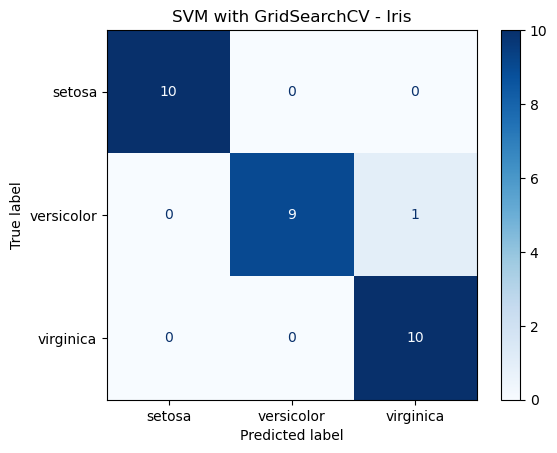

In [5]:
# =============================
# 2. Load Iris Dataset
# =============================
iris = sns.load_dataset('iris')
X = iris.drop(columns=['species'])
y = iris['species']

# =============================
# 3. Create Pipeline (SVM + Scaler)
# =============================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# =============================
# 4. Define Parameter Grid for Tuning
# =============================
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 0.01],
    'svm__kernel': ['rbf', 'linear']
}

# =============================
# 5. GridSearchCV with 5-Fold Cross Validation
# =============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# =============================
# 6. Fit GridSearchCV
# =============================
grid_search.fit(X, y)

# =============================
# 7. Results
# =============================
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# =============================
# 8. Final Evaluation on Test Set
# =============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Use best model found
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Accuracy and report
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=y.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y.unique())
disp.plot(cmap='Blues')
plt.title("SVM with GridSearchCV - Iris")
plt.show()

In [6]:
# =============================
# 1. Import Libraries
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Best Parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.6893333333333334

Test Accuracy: 0.68

Classification Report:
               precision    recall  f1-score   support

        Fair       0.86      0.63      0.73        19
        Good       0.60      0.47      0.52        58
       Ideal       0.80      0.90      0.85       235
     Premium       0.60      0.82      0.69       158
   Very Good       0.47      0.22      0.29       130

    accuracy                           0.68       600
   macro avg       0.66      0.61      0.62       600
weighted avg       0.66      0.68      0.65       600



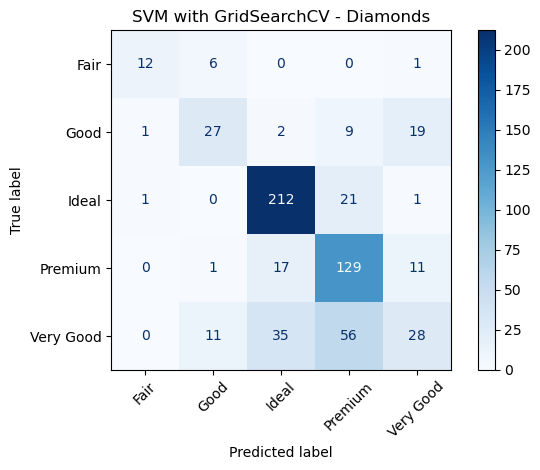

In [7]:
# =============================
# 2. Load Diamonds Dataset
# =============================
# Update path as needed
df = pd.read_csv("C:\\Users\\Somdip.Dey\\Desktop\\Regents_SWE6204\\diamonds.csv")
df.columns = df.columns.str.lower().str.strip()

# Classification target: 'cut'
X = df.drop(columns=['cut'])
y = df['cut']

# =============================
# 3. Identify Features
# =============================
categorical_features = ['color', 'clarity']
numerical_features = [col for col in X.columns if col not in categorical_features]

# =============================
# 4. Preprocessing: OneHot for cat, StandardScaler for num
# =============================
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

# =============================
# 5. Create SVM Pipeline
# =============================
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('svm', SVC())
])

# =============================
# 6. Define Hyperparameter Grid
# =============================
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 0.01],
    'svm__kernel': ['rbf', 'linear']
}

# Use smaller sample for speed (you can remove this for full dataset)
X_sample = X.sample(3000, random_state=42)
y_sample = y.loc[X_sample.index]

# =============================
# 7. GridSearchCV with 5-Fold CV
# =============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_sample, y_sample)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# =============================
# 8. Test Set Evaluation
# =============================
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Accuracy and report
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("SVM with GridSearchCV - Diamonds")
plt.tight_layout()
plt.show()